# NN Stage 2 — long synapse regression (MLP + CNN variants)

Same splits and scenarios as `abr_wide_long_comparison.ipynb`.

- **Stage 1 (wide):** SPL **50 / 60 / 70 / 80** only; fit on **Train**, HP tuning on **Validate** (no sklearn CV), reported metrics on **Test**.
- **Stage 2 (long):** PyTorch on long rows; fit on **Train**, early stopping on **Validate**, metrics on **Test**. Tabular MLP + hybrid **CNN + tabular** (`mode="cnn"` / `"cnn_full"`).
- **No wide-format Stage 2 MLP** (removed; classical wide Stage 2 stays in comparison notebook only).

**CNN:** 0–8 ms crop → resample to **T**; Wave I uses 30 samples at `p1_latency`; full-wave uses entire segment. `RunConfig(full_wave_ref="lib"|"brad")` picks **T**.

Run with working directory = `ABR2synapse` so `../abr_data` and `../liberman_wpz` resolve.

## Load tables and splits

Run the **imports** cell below first, then **load data**.

In [1]:
%matplotlib inline

import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
from IPython.display import display

warnings.filterwarnings("ignore")
sns.set_theme(context="notebook", style="whitegrid")
plt.rcParams["figure.dpi"] = 100

import importlib
import utils.nn_stage2_data
import utils.nn_stage2
importlib.reload(utils.nn_stage2_data)
importlib.reload(utils.nn_stage2)

from utils.nn_stage2_data import (
    FULL_WAVE_WINDOW_MS,
    LIB_FULL_WAVEFORM_MS,
    full_wave_matrix,
    load_nn_stage2_data,
    wide_stage1_fit,
    wide_stage1_val,
    splits_for_long_stage2,
    unified_grid_wave_i_matrix,
)
from utils.nn_stage2 import (
    RunConfig,
    bb_long_s2_rows,
    lib_long_s2_rows,
    long_s2_triple_nn,
    run_two_stage_long_nn,
)

print("torch:", torch.__version__, "| cuda:", torch.cuda.is_available())

torch: 2.9.0 | cuda: False


In [2]:
data = (
    load_nn_stage2_data()
)  # include_extra_wide_features=True → newfeats Stage 1 + 2 extras
sp = splits_for_long_stage2(data)

bb_w_tr, bb_w_te = sp["bb_wide_train"], sp["bb_wide_test"]
lib_tr, lib_te = sp["lib_train"], sp["lib_test"]
bb_lt, bb_lte = sp["bb_long_train"], sp["bb_long_test"]
lib_lt, lib_lte = sp["lib_long_train"], sp["lib_long_test"]

split_summary = pd.DataFrame(
    [
        ("Brad", "wide", len(bb_w_tr), len(bb_w_te)),
        ("Brad", "long", len(bb_lt), len(bb_lte)),
        ("Liberman", "wide", len(lib_tr), len(lib_te)),
        ("Liberman", "long", len(lib_lt), len(lib_lte)),
    ],
    columns=["cohort", "format", "train_rows", "test_rows"],
)
display(split_summary)
pd.DataFrame(
    [
        {
            "Lib_full_trace_ms": LIB_FULL_WAVEFORM_MS,
            "cnn_full_window_ms": str(FULL_WAVE_WINDOW_MS),
            "median_crop_len_Brad": data.full_wave_median_len_bb,
            "median_crop_len_Lib": data.full_wave_median_len_lib,
            "target_len_resample_Lib": data.full_wave_target_len_lib,
            "target_len_resample_Brad": data.full_wave_target_len_brad,
            "default_target_len (load pref)": data.full_wave_target_len,
        }
    ]
)

,cohort,format,train_rows,test_rows
0,Brad,wide,283,77
1,Brad,long,2811,743
2,Liberman,wide,491,125
3,Liberman,long,9751,2436


,Lib_full_trace_ms,cnn_full_window_ms,median_crop_len_Brad,median_crop_len_Lib,target_len_resample_Lib,target_len_resample_Brad,default_target_len (load pref)
0,17.0,"(0.0, 8.0)",100,201,201,100,201


## Waveform length audit (within Brad vs within Liberman)

Checks whether **every long row** in a cohort shares the same sample count **before** resampling. If **uniform** after the 0–8 ms crop, you do not need a *within-cohort* length fix—only the **cross-cohort** step (`cnn_full_target_len`) may still resample one lab to match the other when medians differ.

In [3]:
import numpy as np
import pandas as pd

from utils.nn_stage2_data import crop_brad_waveform_0_8ms, crop_lib_waveform_0_8ms

bb, lib = data.brad_buran_df, data.orig_lib

orig_bb = [
    len(np.asarray(r["waveform"], dtype=float).ravel()) for _, r in bb.iterrows()
]
orig_lib = [
    len(np.asarray(r["full_waveform"], dtype=float).ravel()) for _, r in lib.iterrows()
]
crop_bb = [crop_brad_waveform_0_8ms(r).size for _, r in bb.iterrows()]
crop_lib = [crop_lib_waveform_0_8ms(r).size for _, r in lib.iterrows()]

rows = []
for label, L in [
    ("Brad — original full waveform", orig_bb),
    ("Brad — after 0–8 ms crop", crop_bb),
    ("Liberman — original full waveform", orig_lib),
    ("Liberman — after 0–8 ms crop", crop_lib),
]:
    vc = pd.Series(L).value_counts().sort_index()
    rows.append(
        {
            "stage": label,
            "n_rows": len(L),
            "n_unique_lengths": int(vc.size),
            "uniform_within_cohort": bool(vc.size == 1),
            "length_values": list(vc.index.astype(int)),
            "count_per_length": (
                vc.to_dict() if vc.size <= 8 else "(>8 distinct; see vc)"
            ),
        }
    )

wave_len_audit = pd.DataFrame(rows)
display(wave_len_audit.drop(columns=["count_per_length"], errors="ignore"))
for _, r in wave_len_audit.iterrows():
    cpl = r["count_per_length"]
    if isinstance(cpl, dict):
        print(f"{r['stage']}: counts by length → {cpl}")
    elif r["n_unique_lengths"] > 8:
        print(
            f"{r['stage']}: {r['n_unique_lengths']} distinct lengths (min/max in length_values)"
        )

tw = data.full_wave_target_len
print(f"\nAfter resampling (cnn_full branch): every row length = {tw} (fixed).")
cross_diff = data.full_wave_median_len_bb != data.full_wave_median_len_lib
if cross_diff:
    print(
        "Cross-cohort: median crop lengths differ → target_len picks one lab; the other is interpolated."
    )
else:
    print(
        "Cross-cohort: median crop lengths match → target equals that length; resampling is length-preserving when each row’s crop already has that length."
    )

,stage,n_rows,n_unique_lengths,uniform_within_cohort,length_values
0,Brad — original full waveform,3554,1,True,[125]
1,Brad — after 0–8 ms crop,3554,1,True,[100]
2,Liberman — original full waveform,12187,1,True,[426]
3,Liberman — after 0–8 ms crop,12187,1,True,[201]


Brad — original full waveform: counts by length → {125: 3554}
Brad — after 0–8 ms crop: counts by length → {100: 3554}
Liberman — original full waveform: counts by length → {426: 12187}
Liberman — after 0–8 ms crop: counts by length → {201: 12187}

After resampling (cnn_full branch): every row length = 201 (fixed).
Cross-cohort: median crop lengths differ → target_len picks one lab; the other is interpolated.


## Stage 1 wide classifiers

Canonical fit, RF/LR comparison, and cache export live in **`abr_stage1_wide.ipynb`**.
This notebook calls `fit_stage1_wide_best` via `run_two_stage_long_nn` only.


## Stage 2 training config

`split_random_state=22` aligns mouse splits; **`val_frac` is fallback-only** when Validate long rows are empty after `dropna`. Tweak `epochs` / `batch_size` for iteration speed.

In [4]:
cfg = RunConfig(
    epochs=80,
    batch_size=256,
    lr=1e-3,
    weight_decay=1e-4,
    huber=True,
    split_random_state=22,
    random_state=1,
)

## Tabular MLP — Brad test, then Liberman test

`return_agg=True` keeps per–(animal × frequency) predictions for plots below.

In [5]:
print("=" * 70)
print("MLP — Brad Buran's test set")
print("=" * 70)
mlp_bb = long_s2_triple_nn(
    run_two_stage_long_nn,
    bb_long_s2_rows(data, sp),
    data,
    mode="mlp",
    cfg=cfg,
    return_agg=True,
)

print("\n" + "=" * 70)
print("MLP — Liberman test set")
print("=" * 70)
mlp_lib = long_s2_triple_nn(
    run_two_stage_long_nn,
    lib_long_s2_rows(data, sp),
    data,
    mode="mlp",
    cfg=cfg,
    return_agg=True,
)

MLP — Brad Buran's test set

[A] Train on Brad Buran's dataset only:
  [A]  S1 fit/val wide: 230/53 | long train: 2811 rows | Stage2=mlp
           Selected RF  — fit acc (animal@cal): 0.944 | non-test acc (animal@cal): 0.933 | threshold (Fit+Val): 0.423 | test acc (animal@cal): 0.917 | test acc@0.5: 0.583 | AUC: 0.944
           Stage2 rows — train: 2299 | validate: 512 | animals train/val: 36/9
           Synapse NN — test R²: 0.507, RMSE: 3.332

[B] Train on Brad Buran's + Liberman dataset:
  [B]  S1 fit/val wide: 627/147 | long train: 12562 rows | Stage2=mlp
           Selected RF  — fit acc (animal@cal): 0.865 | non-test acc (animal@cal): 0.860 | threshold (Fit+Val): 0.458 | test acc (animal@cal): 0.833 | test acc@0.5: 0.500 | AUC: 0.722
           Stage2 rows — train: 10168 | validate: 2394 | animals train/val: 104/25
           Synapse NN — test R²: 0.587, RMSE: 3.051

[C] Train on Liberman dataset only:
  [C]  S1 fit/val wide: 397/94 | long train: 9751 rows | Stage2=mlp
       

## 1D-CNN — unified 0–8 ms grid + tabular (hybrid encoder)

**Hybrid model:** 1D CNN on the resampled waveform **plus** tabular ABR features (same long columns as MLP). Not waveform-only.

**Wave I (`mode="cnn"`):** 0–8 ms crop → length **T** → 30 samples centred at `p1_latency`.

**Full wave (`mode="cnn_full"`):** same crop/resample; encoder sees the full length-**T** segment.

**T:** `RunConfig(full_wave_ref="lib"|"brad")` uses Liberman vs Brad median crop lengths.

In [6]:
from dataclasses import replace

bb_rows = bb_long_s2_rows(data, sp)
lib_rows = lib_long_s2_rows(data, sp)
cfg_lib = replace(cfg, full_wave_ref="lib")
cfg_brad = replace(cfg, full_wave_ref="brad")

print("=" * 70)
print("Brad test | resample T = Lib median")
print("=" * 70)
cnn_wave_libT_bb = long_s2_triple_nn(
    run_two_stage_long_nn,
    bb_rows,
    data,
    mode="cnn",
    cfg=cfg_lib,
    return_agg=True,
)
cnn_full_libT_bb = long_s2_triple_nn(
    run_two_stage_long_nn,
    bb_rows,
    data,
    mode="cnn_full",
    cfg=cfg_lib,
    return_agg=True,
)

print("\n" + "=" * 70)
print("Brad test | resample T = Brad median")
print("=" * 70)
cnn_wave_bradT_bb = long_s2_triple_nn(
    run_two_stage_long_nn,
    bb_rows,
    data,
    mode="cnn",
    cfg=cfg_brad,
    return_agg=True,
)
cnn_full_bradT_bb = long_s2_triple_nn(
    run_two_stage_long_nn,
    bb_rows,
    data,
    mode="cnn_full",
    cfg=cfg_brad,
    return_agg=True,
)

print("\n" + "=" * 70)
print("Liberman test | resample T = Lib median")
print("=" * 70)
cnn_wave_libT_lib = long_s2_triple_nn(
    run_two_stage_long_nn,
    lib_rows,
    data,
    mode="cnn",
    cfg=cfg_lib,
    return_agg=True,
)
cnn_full_libT_lib = long_s2_triple_nn(
    run_two_stage_long_nn,
    lib_rows,
    data,
    mode="cnn_full",
    cfg=cfg_lib,
    return_agg=True,
)

print("\n" + "=" * 70)
print("Liberman test | resample T = Brad median")
print("=" * 70)
cnn_wave_bradT_lib = long_s2_triple_nn(
    run_two_stage_long_nn,
    lib_rows,
    data,
    mode="cnn",
    cfg=cfg_brad,
    return_agg=True,
)
cnn_full_bradT_lib = long_s2_triple_nn(
    run_two_stage_long_nn,
    lib_rows,
    data,
    mode="cnn_full",
    cfg=cfg_brad,
    return_agg=True,
)

Brad test | resample T = Lib median

[A] Train on Brad Buran's dataset only:
  [A]  S1 fit/val wide: 230/53 | long train: 2811 rows | Stage2=cnn | full_wave_ref=lib
           Selected RF  — fit acc (animal@cal): 0.944 | non-test acc (animal@cal): 0.933 | threshold (Fit+Val): 0.423 | test acc (animal@cal): 0.917 | test acc@0.5: 0.583 | AUC: 0.944
           Stage2 rows — train: 2299 | validate: 512 | animals train/val: 36/9
           Unified 0–8 ms resampled length T=201
           Synapse NN — test R²: 0.585, RMSE: 3.058

[B] Train on Brad Buran's + Liberman dataset:
  [B]  S1 fit/val wide: 627/147 | long train: 12562 rows | Stage2=cnn | full_wave_ref=lib
           Selected RF  — fit acc (animal@cal): 0.865 | non-test acc (animal@cal): 0.860 | threshold (Fit+Val): 0.458 | test acc (animal@cal): 0.833 | test acc@0.5: 0.500 | AUC: 0.722
           Stage2 rows — train: 10168 | validate: 2394 | animals train/val: 104/25
           Unified 0–8 ms resampled length T=201
           Synapse

## Metrics tables (R², RMSE after animal × frequency aggregation)

In [7]:
from pathlib import Path


def triple_to_metrics(triple_dict, test_set, model, *, stage2_format="long"):
    rows = []
    for scen, x in triple_dict.items():
        r2, rmse, _ = x
        rows.append(
            {
                "test_set": test_set,
                "model": model,
                "scenario": scen,
                "R2": round(r2, 4),
                "RMSE": round(rmse, 4),
                "stage2_format": stage2_format,
            }
        )
    return pd.DataFrame(rows)


metrics_all = pd.concat(
    [
        triple_to_metrics(mlp_bb, "Brad", "MLP"),
        triple_to_metrics(mlp_lib, "Liberman", "MLP"),
        triple_to_metrics(cnn_wave_libT_bb, "Brad", "CNN_WaveI_LibT"),
        triple_to_metrics(cnn_full_libT_bb, "Brad", "CNN_full_LibT"),
        triple_to_metrics(cnn_wave_bradT_bb, "Brad", "CNN_WaveI_BradT"),
        triple_to_metrics(cnn_full_bradT_bb, "Brad", "CNN_full_BradT"),
        triple_to_metrics(cnn_wave_libT_lib, "Liberman", "CNN_WaveI_LibT"),
        triple_to_metrics(cnn_full_libT_lib, "Liberman", "CNN_full_LibT"),
        triple_to_metrics(cnn_wave_bradT_lib, "Liberman", "CNN_WaveI_BradT"),
        triple_to_metrics(cnn_full_bradT_lib, "Liberman", "CNN_full_BradT"),
    ],
    ignore_index=True,
)
metrics_pivot = metrics_all.pivot_table(
    index=["test_set", "scenario"], columns="model", values=["R2", "RMSE"]
)
metrics_all = metrics_all[metrics_all["stage2_format"] == "long"].copy()
metrics_all.sort_values(["test_set", "stage2_format", "model", "scenario"]).reset_index(
    drop=True
)

_nn_cache = Path("figures/cache")
_nn_cache.mkdir(parents=True, exist_ok=True)
_nn_parquet = _nn_cache / "nn_metrics_all.parquet"
metrics_all.to_parquet(_nn_parquet, index=False)
print("Saved", _nn_parquet.resolve(), "— long MLP/CNN only (no MLP_wide)")

Saved /Users/nowaki027/MSDS/Practicum/figures/cache/nn_metrics_all.parquet — long MLP/CNN only (no MLP_wide)


In [8]:
metrics_pivot

R2                                              \
model             CNN_WaveI_BradT CNN_WaveI_LibT CNN_full_BradT CNN_full_LibT   
test_set scenario                                                               
Brad     A                 0.5762         0.5850         0.5647        0.5756   
         B                 0.5682         0.5814         0.5987        0.5592   
         C                -0.4312        -0.3807        -0.1584       -0.3719   
Liberman A                -0.0953        -0.1158        -0.1663       -0.3649   
         B                 0.3355         0.3924         0.3984        0.3824   
         C                 0.3997         0.4192         0.3374        0.4226   

                                     RMSE                                \
model                 MLP CNN_WaveI_BradT CNN_WaveI_LibT CNN_full_BradT   
test_set scenario                                                         
Brad     A         0.5074          3.0903         3.0579         3.1319   
         B         0.5869          3.1192         3.0711         3.0071   
         C        -0.3771          5.6788         5.5776         5.1090   
Liberman A        -0.6837          3.8369         3.8727         3.9592   
         B         0.3374          2.9886         2.8577         2.8437   
         C         0.3842          2.8406         2.7941         2.9843   

                                         
model             CNN_full_LibT     MLP  
test_set scenario                        
Brad     A               3.0925  3.3316  
         B               3.1517  3.0508  
         C               5.5600  5.5703  
Liberman A               4.2832  4.7572  
         B               2.8812  2.9843  
         C               2.7857  2.8769

## Visualizations

Adjust `SCEN` / `TEST` to inspect other runs.

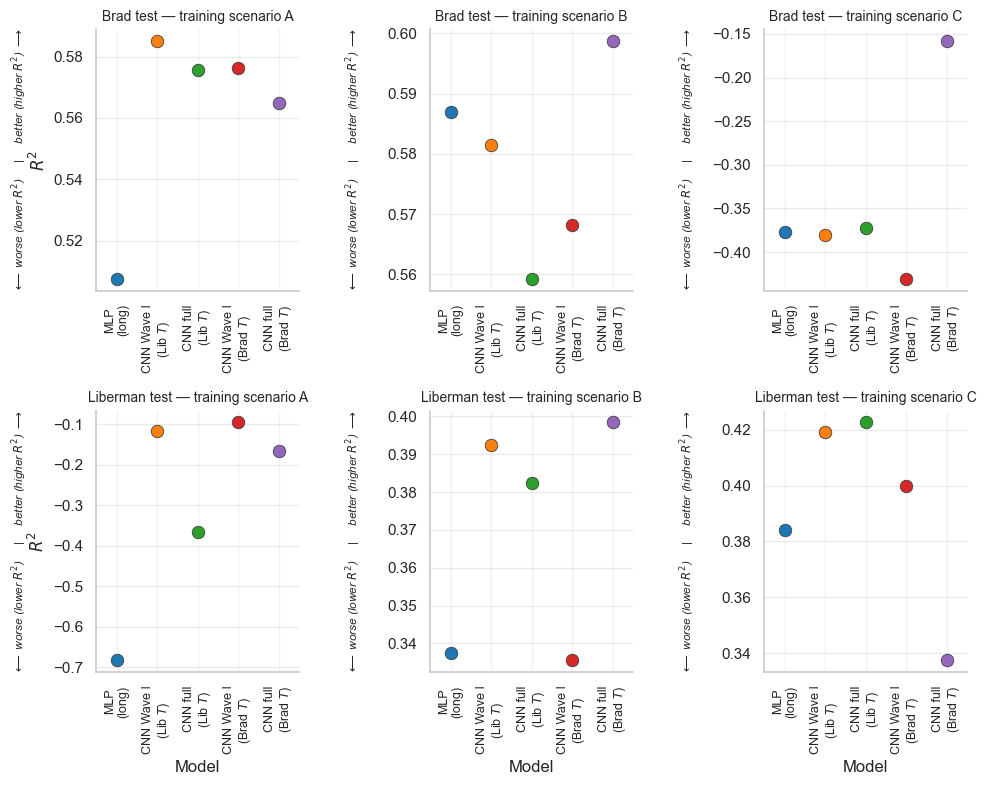

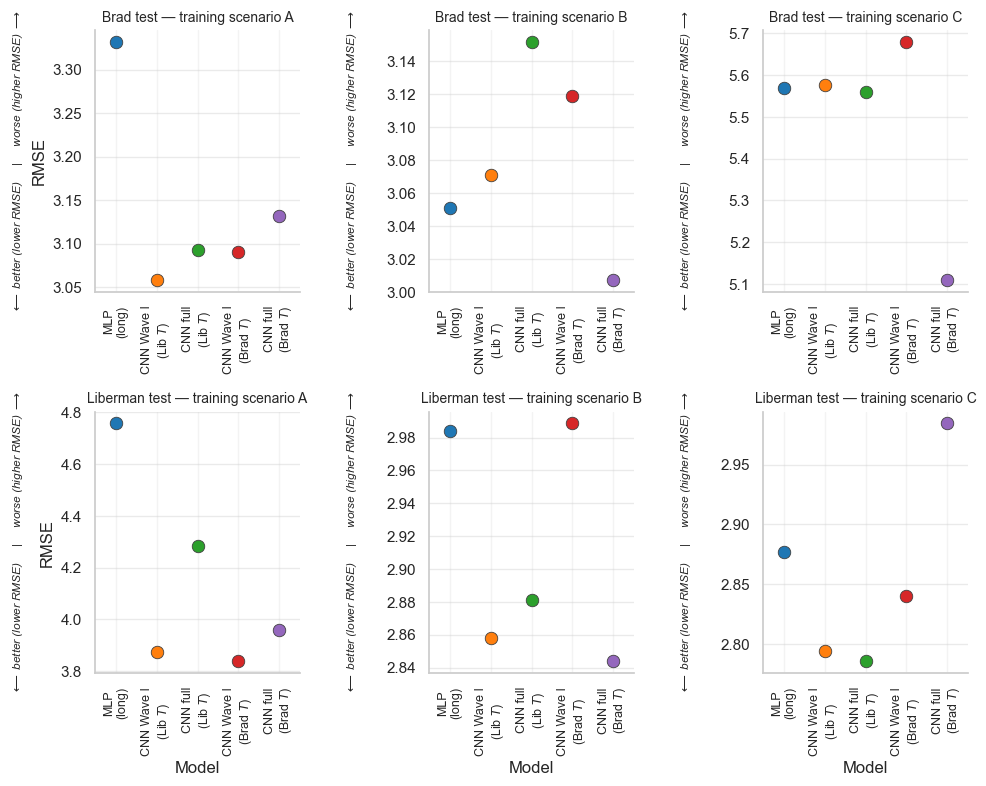

In [9]:
scenario_order = ["A", "B", "C"]
model_order = [
    "MLP",
    "CNN_WaveI_LibT",
    "CNN_full_LibT",
    "CNN_WaveI_BradT",
    "CNN_full_BradT",
]
model_labels = {
    "MLP": "MLP\n(long)",
    "CNN_WaveI_LibT": "CNN Wave I\n(Lib $T$)",
    "CNN_full_LibT": "CNN full\n(Lib $T$)",
    "CNN_WaveI_BradT": "CNN Wave I\n(Brad $T$)",
    "CNN_full_BradT": "CNN full\n(Brad $T$)",
}
_disp_order = [model_labels[m] for m in model_order]
_model_colors = sns.color_palette("tab10", n_colors=len(model_order))
test_order = ["Brad", "Liberman"]


def _metric_point_figure(metric_col: str, y_label: str, better_text: str) -> None:
    """2×3 grid: rows = test cohort; cols = training scenario. x = model (independent y per panel)."""
    fig, axes = plt.subplots(2, 3, figsize=(12, 9), sharey=False, sharex=False)
    dfp = metrics_all[metrics_all["model"].isin(model_order)].copy()
    dfp["model_disp"] = pd.Categorical(
        dfp["model"].map(model_labels),
        categories=_disp_order,
        ordered=True,
    )
    for row, tname in enumerate(test_order):
        for col, scen in enumerate(scenario_order):
            ax = axes[row, col]
            sub = dfp[(dfp["test_set"] == tname) & (dfp["scenario"] == scen)]
            sns.stripplot(
                data=sub,
                x="model_disp",
                y=metric_col,
                order=_disp_order,
                hue="model_disp",
                hue_order=_disp_order,
                palette=_model_colors,
                jitter=False,
                dodge=False,
                size=9,
                linewidth=0.6,
                edgecolor="0.25",
                legend=False,
                ax=ax,
            )
            ax.set_xticks(np.arange(len(_disp_order)))
            ax.set_xticklabels(_disp_order, rotation=90, ha="center", fontsize=9)
            ax.tick_params(axis="x", labelbottom=True)
            ax.set_xlabel("Model" if row == len(test_order) - 1 else "")
            ax.set_title(f"{tname} test — training scenario {scen}", fontsize=10)
            ax.grid(True, axis="y", alpha=0.4)
            ax.grid(True, axis="x", alpha=0.22)
            sns.despine(ax=ax, top=True, right=True)
            ax.set_ylabel(y_label if col == 0 else "")
            ax.text(
                -0.38,
                0.5,
                better_text,
                transform=ax.transAxes,
                rotation=90,
                va="center",
                ha="center",
                fontsize=8.5,
                style="italic",
                clip_on=False,
            )
    fig.tight_layout(rect=[0.14, 0.08, 0.99, 0.97])
    plt.show()


_metric_point_figure(
    "R2",
    r"$R^2$",
    r"$\longleftarrow$ worse (lower $R^2$)     |     better (higher $R^2$) $\longrightarrow$",
)
_metric_point_figure(
    "RMSE",
    "RMSE",
    r"$\longleftarrow$ better (lower RMSE)     |     worse (higher RMSE) $\longrightarrow$",
)

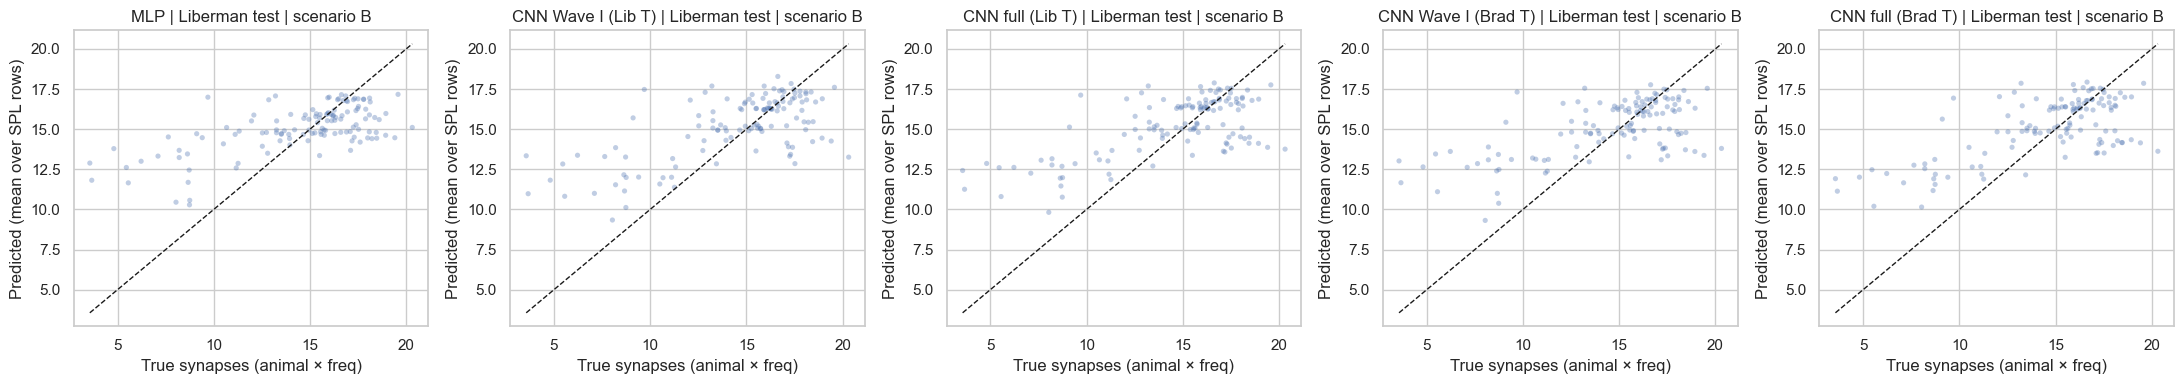

In [10]:
SCEN = "B"
TEST = "Liberman"

if TEST == "Brad":
    mlp_agg = mlp_bb[SCEN][2]
    aggs = [
        mlp_agg,
        cnn_wave_libT_bb[SCEN][2],
        cnn_full_libT_bb[SCEN][2],
        cnn_wave_bradT_bb[SCEN][2],
        cnn_full_bradT_bb[SCEN][2],
    ]
else:
    mlp_agg = mlp_lib[SCEN][2]
    aggs = [
        mlp_agg,
        cnn_wave_libT_lib[SCEN][2],
        cnn_full_libT_lib[SCEN][2],
        cnn_wave_bradT_lib[SCEN][2],
        cnn_full_bradT_lib[SCEN][2],
    ]

names = [
    "MLP",
    "CNN Wave I (Lib T)",
    "CNN full (Lib T)",
    "CNN Wave I (Brad T)",
    "CNN full (Brad T)",
]
fig, ax = plt.subplots(1, 5, figsize=(22, 4))
for a, df, name in zip(ax, aggs, names):
    a.scatter(df["y_true"], df["y_pred"], alpha=0.35, s=14, edgecolors="none")
    lo = float(min(df["y_true"].min(), df["y_pred"].min()))
    hi = float(max(df["y_true"].max(), df["y_pred"].max()))
    a.plot([lo, hi], [lo, hi], "k--", lw=1)
    a.set_xlabel("True synapses (animal × freq)")
    a.set_ylabel("Predicted (mean over SPL rows)")
    a.set_title(f"{name} | {TEST} test | scenario {SCEN}")
plt.tight_layout()
plt.show()

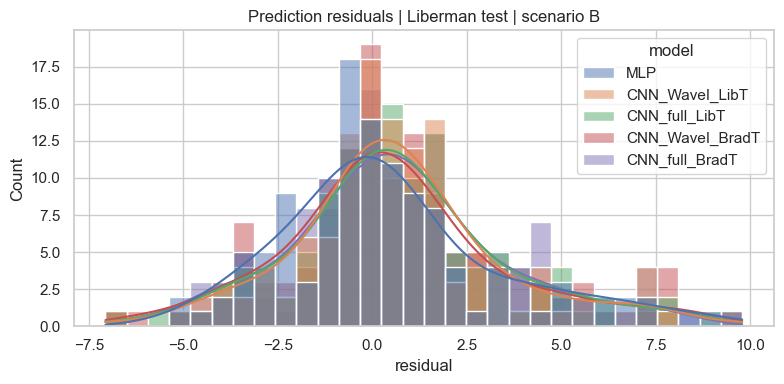

In [11]:
SCEN = "B"
TEST = "Liberman"
if TEST == "Brad":
    plot_df = pd.concat(
        [
            mlp_bb[SCEN][2].assign(model="MLP"),
            cnn_wave_libT_bb[SCEN][2].assign(model="CNN_WaveI_LibT"),
            cnn_full_libT_bb[SCEN][2].assign(model="CNN_full_LibT"),
            cnn_wave_bradT_bb[SCEN][2].assign(model="CNN_WaveI_BradT"),
            cnn_full_bradT_bb[SCEN][2].assign(model="CNN_full_BradT"),
        ],
        ignore_index=True,
    )
else:
    plot_df = pd.concat(
        [
            mlp_lib[SCEN][2].assign(model="MLP"),
            cnn_wave_libT_lib[SCEN][2].assign(model="CNN_WaveI_LibT"),
            cnn_full_libT_lib[SCEN][2].assign(model="CNN_full_LibT"),
            cnn_wave_bradT_lib[SCEN][2].assign(model="CNN_WaveI_BradT"),
            cnn_full_bradT_lib[SCEN][2].assign(model="CNN_full_BradT"),
        ],
        ignore_index=True,
    )
plot_df["residual"] = plot_df["y_pred"] - plot_df["y_true"]

fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(data=plot_df, x="residual", hue="model", kde=True, ax=ax, bins=30)
ax.set_title(f"Prediction residuals | {TEST} test | scenario {SCEN}")
plt.tight_layout()
plt.show()

### Unified Wave I windows (30 samples on 0–8 ms grid)

Same pipeline as training: crop 0–8 ms, resample to **T** = `full_wave_target_len_lib` or `full_wave_target_len_brad`, then 30 samples centred at `p1_latency`.

### Full-wave 0–8 ms (same **T**)

Brad: time from `x` (ms). Liberman: `full_waveform` / `Waveform` with 0–17 ms timebase before crop.

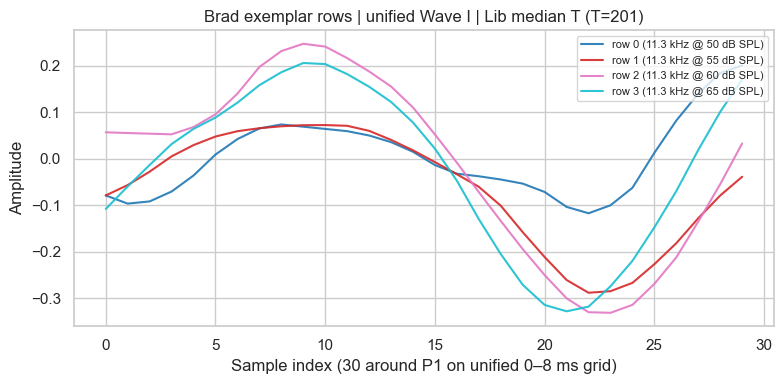

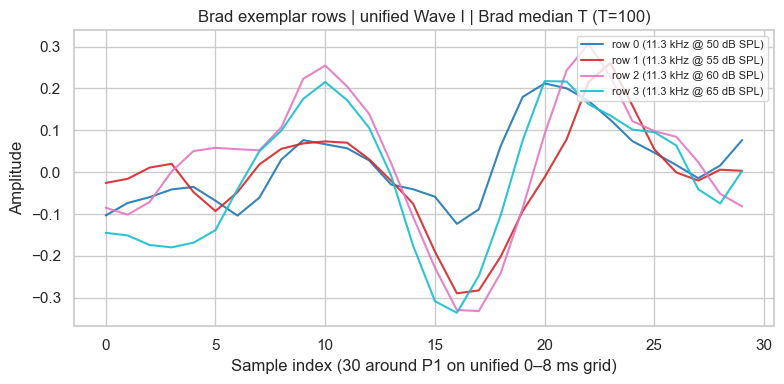

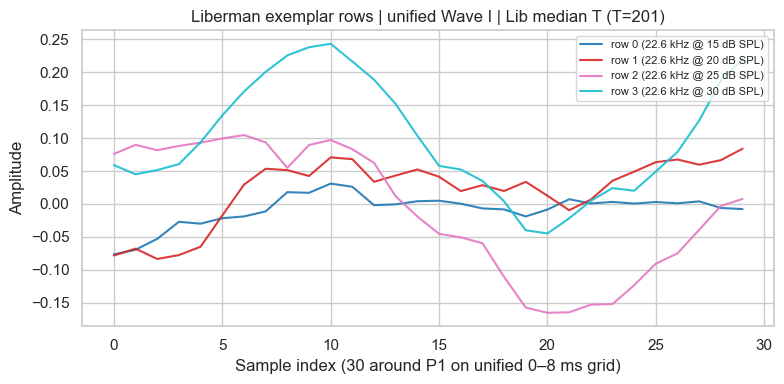

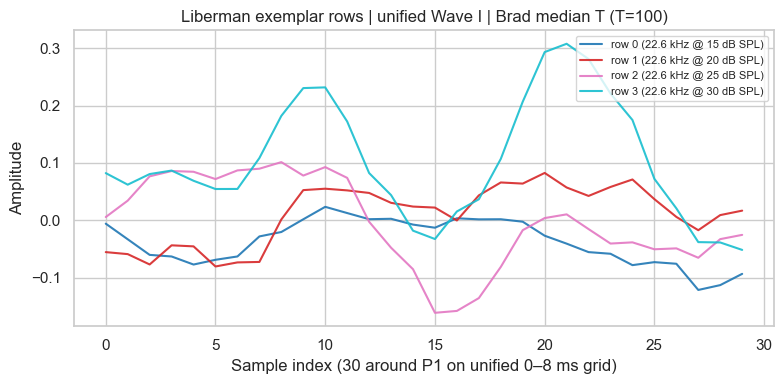

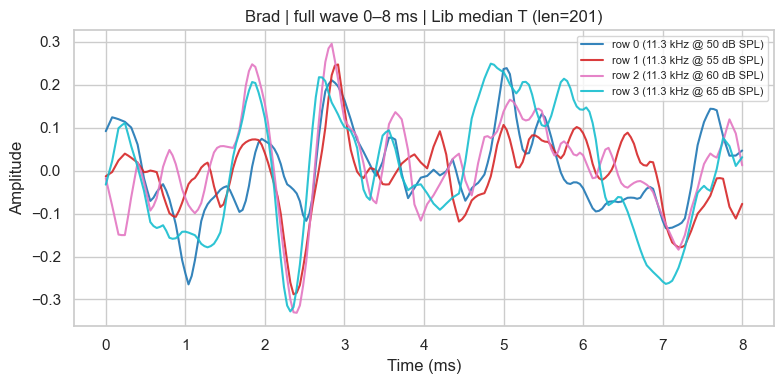

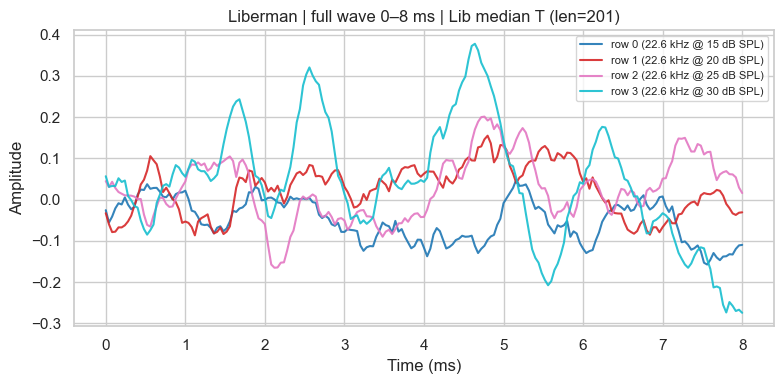

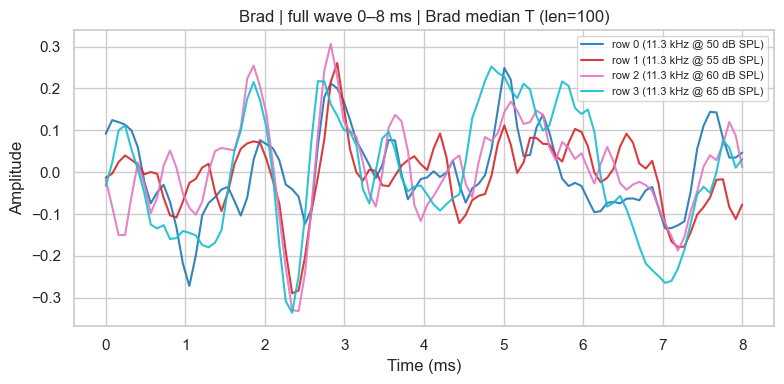

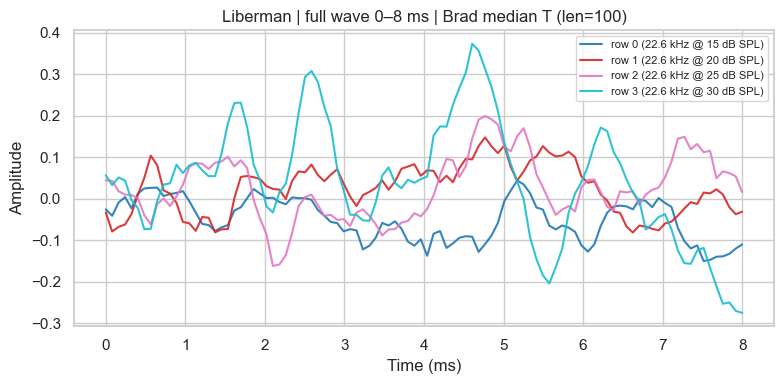

In [12]:
n_show = 4


# Use train+test long rows so we always have enough exemplars (test-only can be tiny).
# Dedupe by (animal, frequency, level) so curves are not accidental repeats.
def _pick_wave_demo_rows(train_df, test_df, full_df, n):
    pool = pd.concat([train_df, test_df], axis=0, ignore_index=True).drop_duplicates(
        subset=["animal_id", "frequency", "level"], keep="first"
    )
    if len(pool) >= n:
        return pool.iloc[:n]
    if len(test_df) >= n:
        return test_df.iloc[:n]
    if len(full_df) >= n:
        return full_df.drop_duplicates(
            subset=["animal_id", "frequency", "level"], keep="first"
        ).iloc[:n]
    return pool.iloc[: min(n, len(pool))]


def _wave_legend_label(i, row) -> str:
    fq = float(row["frequency"])
    lv = float(row["level"])
    return f"row {i} ({fq:g} kHz @ {lv:g} dB SPL)"


bb_demo = _pick_wave_demo_rows(bb_lt, bb_lte, data.brad_buran_df, n_show)
lib_demo = _pick_wave_demo_rows(lib_lt, lib_lte, data.orig_lib, n_show)
idx_bb = bb_demo.index
idx_lib = lib_demo.index
tw_lib = int(data.full_wave_target_len_lib)
tw_brad = int(data.full_wave_target_len_brad)
t30 = np.arange(30)
_colors = plt.cm.tab10(np.linspace(0, 0.9, max(n_show, 4)))

for tw, tag in [(tw_lib, "Lib median T"), (tw_brad, "Brad median T")]:
    W_bb = unified_grid_wave_i_matrix(bb_demo, idx_bb, tw)
    fig, ax = plt.subplots(figsize=(8, 4))
    for i in range(W_bb.shape[0]):
        row = bb_demo.iloc[i]
        ax.plot(
            t30,
            W_bb[i],
            alpha=0.9,
            color=_colors[i],
            label=_wave_legend_label(i, row),
        )
    ax.set_xlabel("Sample index (30 around P1 on unified 0–8 ms grid)")
    ax.set_ylabel("Amplitude")
    ax.set_title(f"Brad exemplar rows | unified Wave I | {tag} (T={tw})")
    ax.legend(fontsize=8, loc="upper right")
    plt.tight_layout()
    plt.show()

for tw, tag in [(tw_lib, "Lib median T"), (tw_brad, "Brad median T")]:
    W_lib = unified_grid_wave_i_matrix(lib_demo, idx_lib, tw)
    fig, ax = plt.subplots(figsize=(8, 4))
    for i in range(W_lib.shape[0]):
        row = lib_demo.iloc[i]
        ax.plot(
            t30,
            W_lib[i],
            alpha=0.9,
            color=_colors[i],
            label=_wave_legend_label(i, row),
        )
    ax.set_xlabel("Sample index (30 around P1 on unified 0–8 ms grid)")
    ax.set_ylabel("Amplitude")
    ax.set_title(f"Liberman exemplar rows | unified Wave I | {tag} (T={tw})")
    ax.legend(fontsize=8, loc="upper right")
    plt.tight_layout()
    plt.show()

for tw, tag in [(tw_lib, "Lib median T"), (tw_brad, "Brad median T")]:
    t_ms = np.linspace(FULL_WAVE_WINDOW_MS[0], FULL_WAVE_WINDOW_MS[1], tw)
    F_bb = full_wave_matrix(bb_demo, idx_bb, tw)
    fig, ax = plt.subplots(figsize=(8, 4))
    for i in range(F_bb.shape[0]):
        row = bb_demo.iloc[i]
        ax.plot(
            t_ms,
            F_bb[i],
            alpha=0.9,
            color=_colors[i],
            label=_wave_legend_label(i, row),
        )
    ax.set_xlabel("Time (ms)")
    ax.set_ylabel("Amplitude")
    ax.set_title(f"Brad | full wave 0–8 ms | {tag} (len={tw})")
    ax.legend(fontsize=8, loc="upper right")
    plt.tight_layout()
    plt.show()

    F_lib = full_wave_matrix(lib_demo, idx_lib, tw)
    fig, ax = plt.subplots(figsize=(8, 4))
    for i in range(F_lib.shape[0]):
        row = lib_demo.iloc[i]
        ax.plot(
            t_ms,
            F_lib[i],
            alpha=0.9,
            color=_colors[i],
            label=_wave_legend_label(i, row),
        )
    ax.set_xlabel("Time (ms)")
    ax.set_ylabel("Amplitude")
    ax.set_title(f"Liberman | full wave 0–8 ms | {tag} (len={tw})")
    ax.legend(fontsize=8, loc="upper right")
    plt.tight_layout()
    plt.show()